In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)  # see all columns
sns.set_style('whitegrid')

# encoding='latin-1' is REQUIRED — this file has non-UTF-8 characters
df = pd.read_csv('../data/raw/DataCoSupplyChainDataset.csv', encoding='latin-1')

print('Shape:', df.shape)
df.head()

Shape: (180519, 53)


,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,Customer Country,Customer Email,Customer Fname,Customer Id,Customer Lname,Customer Password,Customer Segment,Customer State,Customer Street,Customer Zipcode,Department Id,Department Name,Latitude,Longitude,Market,Order City,Order Country,Order Customer Id,order date (DateOrders),Order Id,Order Item Cardprod Id,Order Item Discount,Order Item Discount Rate,Order Item Id,Order Item Product Price,Order Item Profit Ratio,Order Item Quantity,Sales,Order Item Total,Order Profit Per Order,Order Region,Order State,Order Status,Order Zipcode,Product Card Id,Product Category Id,Product Description,Product Image,Product Name,Product Price,Product Status,shipping date (DateOrders),Shipping Mode
0,DEBIT,3,4,91.250000,314.640015,Advance shipping,0,73,Sporting Goods,Caguas,Puerto Rico,XXXXXXXXX,Cally,20755,Holloway,XXXXXXXXX,Consumer,PR,5365 Noble Nectar Island,725.0,2,Fitness,18.251453,-66.037056,Pacific Asia,Bekasi,Indonesia,20755,1/31/2018 22:56,77202,1360,13.110000,0.04,180517,327.75,0.29,1,327.75,314.640015,91.250000,Southeast Asia,Java Occidental,COMPLETE,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,2/3/2018 22:56,Standard Class
1,TRANSFER,5,4,-249.089996,311.359985,Late delivery,1,73,Sporting Goods,Caguas,Puerto Rico,XXXXXXXXX,Irene,19492,Luna,XXXXXXXXX,Consumer,PR,2679 Rustic Loop,725.0,2,Fitness,18.279451,-66.037064,Pacific Asia,Bikaner,India,19492,1/13/2018 12:27,75939,1360,16.389999,0.05,179254,327.75,-0.80,1,327.75,311.359985,-249.089996,South Asia,Rajastán,PENDING,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/18/2018 12:27,Standard Class
2,CASH,4,4,-247.779999,309.720001,Shipping on time,0,73,Sporting Goods,San Jose,EE. UU.,XXXXXXXXX,Gillian,19491,Maldonado,XXXXXXXXX,Consumer,CA,8510 Round Bear Gate,95125.0,2,Fitness,37.292233,-121.881279,Pacific Asia,Bikaner,India,19491,1/13/2018 12:06,75938,1360,18.030001,0.06,179253,327.75,-0.80,1,327.75,309.720001,-247.779999,South Asia,Rajastán,CLOSED,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/17/2018 12:06,Standard Class
3,DEBIT,3,4,22.860001,304.809998,Advance shipping,0,73,Sporting Goods,Los Angeles,EE. UU.,XXXXXXXXX,Tana,19490,Tate,XXXXXXXXX,Home Office,CA,3200 Amber Bend,90027.0,2,Fitness,34.125946,-118.291016,Pacific Asia,Townsville,Australia,19490,1/13/2018 11:45,75937,1360,22.940001,0.07,179252,327.75,0.08,1,327.75,304.809998,22.860001,Oceania,Queensland,COMPLETE,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/16/2018 11:45,Standard Class
4,PAYMENT,2,4,134.210007,298.250000,Advance shipping,0,73,Sporting Goods,Caguas,Puerto Rico,XXXXXXXXX,Orli,19489,Hendricks,XXXXXXXXX,Corporate,PR,8671 Iron Anchor Corners,725.0,2,Fitness,18.253769,-66.037048,Pacific Asia,Townsville,Australia,19489,1/13/2018 11:24,75936,1360,29.500000,0.09,179251,327.75,0.45,1,327.75,298.250000,134.210007,Oceania,Queensland,PENDING_PAYMENT,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/15/2018 11:24,Standard Class


In [2]:
print('=== Shape ===')
print(df.shape)

print('\n=== Datatypes ===')
print(df.dtypes.value_counts())

print('\n=== Info ===')
df.info()


=== Shape ===
(180519, 53)

=== Datatypes ===
object     24
float64    15
int64      14
Name: count, dtype: int64

=== Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180519 entries, 0 to 180518
Data columns (total 53 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   Type                           180519 non-null  object 
 1   Days for shipping (real)       180519 non-null  int64  
 2   Days for shipment (scheduled)  180519 non-null  int64  
 3   Benefit per order              180519 non-null  float64
 4   Sales per customer             180519 non-null  float64
 5   Delivery Status                180519 non-null  object 
 6   Late_delivery_risk             180519 non-null  int64  
 7   Category Id                    180519 non-null  int64  
 8   Category Name                  180519 non-null  object 
 9   Customer City                  180519 non-null  object 
 10  Customer Country        

In [3]:
# === MISSING VALUE CHECK ===
# Shows every column that has missing values, worst first.

missing = df.isnull().sum()
print(missing[missing > 0].sort_values(ascending=False))

Product Description    180519
Order Zipcode          155679
Customer Lname              8
Customer Zipcode            3
dtype: int64


In [4]:
# === CONSTANT COLUMN CHECK ===
# A column with only 1 unique value teaches a model nothing.

for col in df.columns:
    if df[col].nunique() == 1:
        print(f"{col}: only value = {df[col].unique()}")

Customer Email: only value = ['XXXXXXXXX']
Customer Password: only value = ['XXXXXXXXX']
Product Status: only value = [0]


In [5]:
# === COLUMN REMOVAL ===
# Remove columns that can hurt model quality or add no useful information

# 1. Leakage columns
# These columns directly reveal the target outcome after delivery
leakage_cols = [
    'Days for shipping (real)',
    'Delivery Status',
]

# 2. Constant / highly empty columns
# Single-value or mostly missing columns provide no learning value
useless_cols = [
    'Customer Email',
    'Customer Password',
    'Product Description',
    'Product Status',
    'Order Zipcode',
]

# 3. Personal identifiers / IDs
# Names and unique IDs do not help prediction and should be removed
id_cols = [
    'Customer Fname', 'Customer Lname', 'Customer Street', 'Customer Zipcode',
    'Product Image', 'Customer Id', 'Order Customer Id', 'Order Id',
    'Order Item Id', 'Order Item Cardprod Id', 'Product Card Id',
    'Category Id', 'Department Id', 'Product Category Id',
]

# Combine all columns to remove
cols_to_drop = leakage_cols + useless_cols + id_cols

# Drop columns from dataset
df = df.drop(columns=cols_to_drop)

# Verify updated dataset shape and remaining columns
print('Dropped', len(cols_to_drop), 'columns')
print('New shape:', df.shape)

print('\nRemaining columns:')
print(list(df.columns))

Dropped 21 columns
New shape: (180519, 32)

Remaining columns:
['Type', 'Days for shipment (scheduled)', 'Benefit per order', 'Sales per customer', 'Late_delivery_risk', 'Category Name', 'Customer City', 'Customer Country', 'Customer Segment', 'Customer State', 'Department Name', 'Latitude', 'Longitude', 'Market', 'Order City', 'Order Country', 'order date (DateOrders)', 'Order Item Discount', 'Order Item Discount Rate', 'Order Item Product Price', 'Order Item Profit Ratio', 'Order Item Quantity', 'Sales', 'Order Item Total', 'Order Profit Per Order', 'Order Region', 'Order State', 'Order Status', 'Product Name', 'Product Price', 'shipping date (DateOrders)', 'Shipping Mode']


In [6]:
# === CHECK MISSING VALUES AFTER CLEANING ===
# Verify that no missing values remain after dropping problematic columns

missing = df.isnull().sum()

# Show only columns that still contain missing values
print(missing[missing > 0].sort_values(ascending=False))

# Total missing values in the entire dataset
print('\nTotal missing cells:', df.isnull().sum().sum())

Series([], dtype: int64)

Total missing cells: 0


In [7]:
# === TARGET VALIDATION ===
# Understand how balanced the target variable is before modeling

# Class distribution of Late_delivery_risk
print("Class distribution:")
print(df['Late_delivery_risk'].value_counts(normalize=True).round(4))

# Check distribution of scheduled shipping days
print("\nScheduled shipping days distribution:")
print(df['Days for shipment (scheduled)'].value_counts().sort_index())

Class distribution:
Late_delivery_risk
1    0.5483
0    0.4517
Name: proportion, dtype: float64

Scheduled shipping days distribution:
Days for shipment (scheduled)
0      9737
1     27814
2     35216
4    107752
Name: count, dtype: int64


In [8]:
# order date format is M/D/YYYY H:M
df['order_date'] = pd.to_datetime(df['order date (DateOrders)'], format='%m/%d/%Y %H:%M')

df['order_year']    = df['order_date'].dt.year
df['order_month']   = df['order_date'].dt.month
df['order_weekday'] = df['order_date'].dt.dayofweek
df['order_quarter'] = df['order_date'].dt.quarter

# drop raw date strings (shipping date is post-order = mild leakage)
df = df.drop(columns=['order date (DateOrders)', 'shipping date (DateOrders)'])

print('New shape:', df.shape)
df[['order_year','order_month','order_weekday','order_quarter']].head()

New shape: (180519, 35)


,order_year,order_month,order_weekday,order_quarter
0,2018,1,2,1
1,2018,1,5,1
2,2018,1,5,1
3,2018,1,5,1
4,2018,1,5,1


In [9]:
df.to_csv('../data/processed/cleaned_supply_chain.csv', index=False)
print('Saved:', df.shape)

Saved: (180519, 35)


In [10]:
df = pd.read_csv('../data/processed/cleaned_supply_chain.csv')
df['order_date'] = pd.to_datetime(df['order_date'])
print(df.shape)
print(df.columns.tolist())

(180519, 35)
['Type', 'Days for shipment (scheduled)', 'Benefit per order', 'Sales per customer', 'Late_delivery_risk', 'Category Name', 'Customer City', 'Customer Country', 'Customer Segment', 'Customer State', 'Department Name', 'Latitude', 'Longitude', 'Market', 'Order City', 'Order Country', 'Order Item Discount', 'Order Item Discount Rate', 'Order Item Product Price', 'Order Item Profit Ratio', 'Order Item Quantity', 'Sales', 'Order Item Total', 'Order Profit Per Order', 'Order Region', 'Order State', 'Order Status', 'Product Name', 'Product Price', 'Shipping Mode', 'order_date', 'order_year', 'order_month', 'order_weekday', 'order_quarter']


In [11]:
import warnings
warnings.filterwarnings('ignore')

Overall late-delivery rate: 54.8%



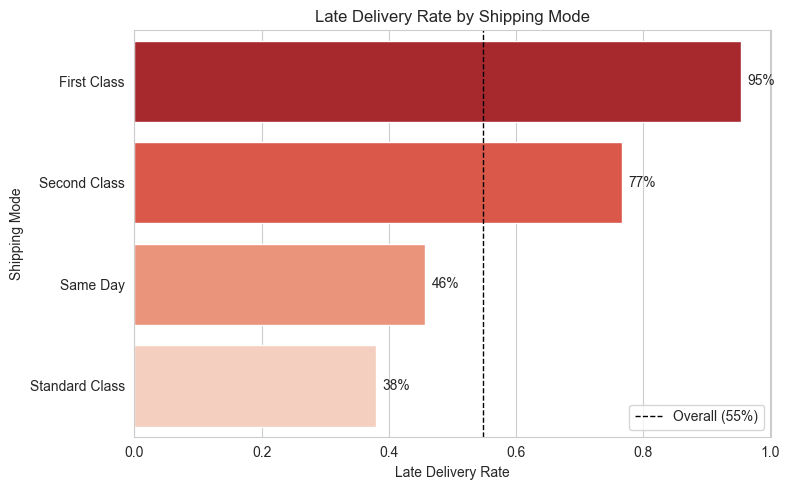

In [12]:
overall_late = df['Late_delivery_risk'].mean()
print(f"Overall late-delivery rate: {overall_late:.1%}\n")

# late rate by shipping mode, sorted worst-first
late_by_mode = df.groupby('Shipping Mode')['Late_delivery_risk'].mean().sort_values(ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(x=late_by_mode.values, y=late_by_mode.index, palette='Reds_r')
plt.xlabel('Late Delivery Rate')
plt.ylabel('Shipping Mode')
plt.title('Late Delivery Rate by Shipping Mode')
plt.axvline(overall_late, color='black', linestyle='--', linewidth=1, label=f'Overall ({overall_late:.0%})')
plt.legend()
for i, v in enumerate(late_by_mode.values):
    plt.text(v + 0.01, i, f'{v:.0%}', va='center')
plt.tight_layout()
plt.show()

### Late Delivery by Shipping Mode

Overall late-delivery rate: **54.8%** — more than half of all orders arrive late.

The driver is shipping mode, and counterintuitively **faster = later**:
- First Class → **95%** late
- Second Class → **77%** late
- Same Day → **46%** late
- Standard Class → **38%** late (the slowest tier is the most reliable)

**Takeaway:** Premium, faster-promised shipping tiers are the *least* reliable. This indicates the delivery network is structurally over-committing on expedited shipping windows — Standard Class has a generous buffer that's easy to meet, while First Class promises tight deadlines it can't hit.

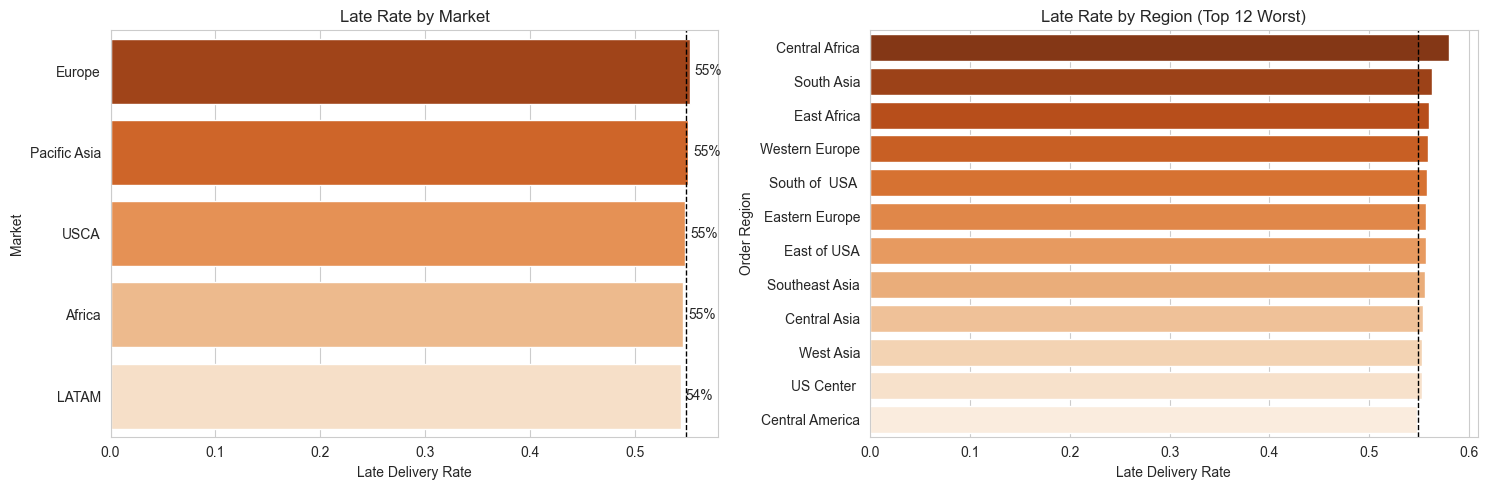

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# By Market
late_by_market = df.groupby('Market')['Late_delivery_risk'].mean().sort_values(ascending=False)
sns.barplot(x=late_by_market.values, y=late_by_market.index, palette='Oranges_r', ax=axes[0])
axes[0].axvline(df['Late_delivery_risk'].mean(), color='black', linestyle='--', linewidth=1)
axes[0].set_title('Late Rate by Market')
axes[0].set_xlabel('Late Delivery Rate')
for i, v in enumerate(late_by_market.values):
    axes[0].text(v + 0.005, i, f'{v:.0%}', va='center')

# By Region (top 12 worst)
late_by_region = df.groupby('Order Region')['Late_delivery_risk'].mean().sort_values(ascending=False).head(12)
sns.barplot(x=late_by_region.values, y=late_by_region.index, palette='Oranges_r', ax=axes[1])
axes[1].axvline(df['Late_delivery_risk'].mean(), color='black', linestyle='--', linewidth=1)
axes[1].set_title('Late Rate by Region (Top 12 Worst)')
axes[1].set_xlabel('Late Delivery Rate')

plt.tight_layout()
plt.show()

### Geography (Market & Region)

Late rate is **flat across all geography**:
- All markets sit at ~55% (Europe, Pacific Asia, USCA, Africa, LATAM — within 1 point of each other)
- Even the 12 *worst* regions only range ~54%–58%

Compared to shipping mode's huge 38%–95% swing, geography barely moves the needle.

**Takeaway:** Late delivery is not a regional logistics weakness — no single market or region stands out. This reinforces that the problem is structural (shipping-mode promises), not geographic. A fix targeting expedited shipping would help globally rather than region-by-region.

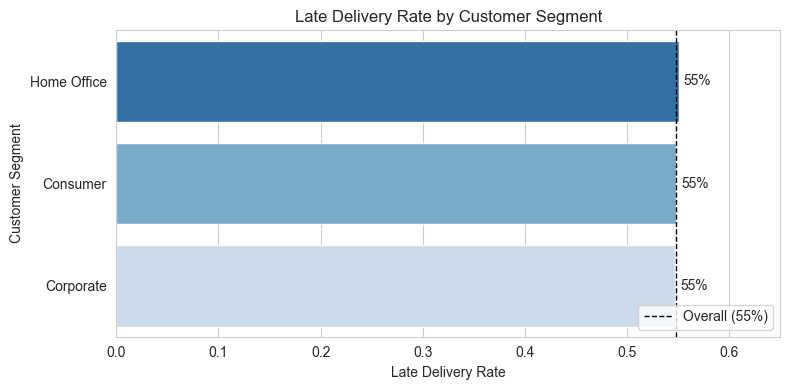

In [14]:
late_by_segment = df.groupby('Customer Segment')['Late_delivery_risk'].mean().sort_values(ascending=False)

plt.figure(figsize=(8, 4))
sns.barplot(x=late_by_segment.values, y=late_by_segment.index,
            hue=late_by_segment.index, palette='Blues_r', legend=False)
plt.axvline(df['Late_delivery_risk'].mean(), color='black', linestyle='--', linewidth=1,
            label=f"Overall ({df['Late_delivery_risk'].mean():.0%})")
plt.xlabel('Late Delivery Rate')
plt.ylabel('Customer Segment')
plt.title('Late Delivery Rate by Customer Segment')
plt.xlim(0, 0.65)
plt.legend(loc='lower right')
for i, v in enumerate(late_by_segment.values):
    plt.text(v + 0.005, i, f'{v:.0%}', va='center')
plt.tight_layout()
plt.show()

### Customer Segment

Late rate is **identical at 55% across all three segments** — Consumer, Corporate, and Home Office.

Customer type has zero effect on whether an order arrives late.

**Takeaway:** Combined with flat geography and flat seasonality, this confirms that *who* the customer is doesn't matter — late delivery is driven entirely by shipping mode, not customer characteristics.

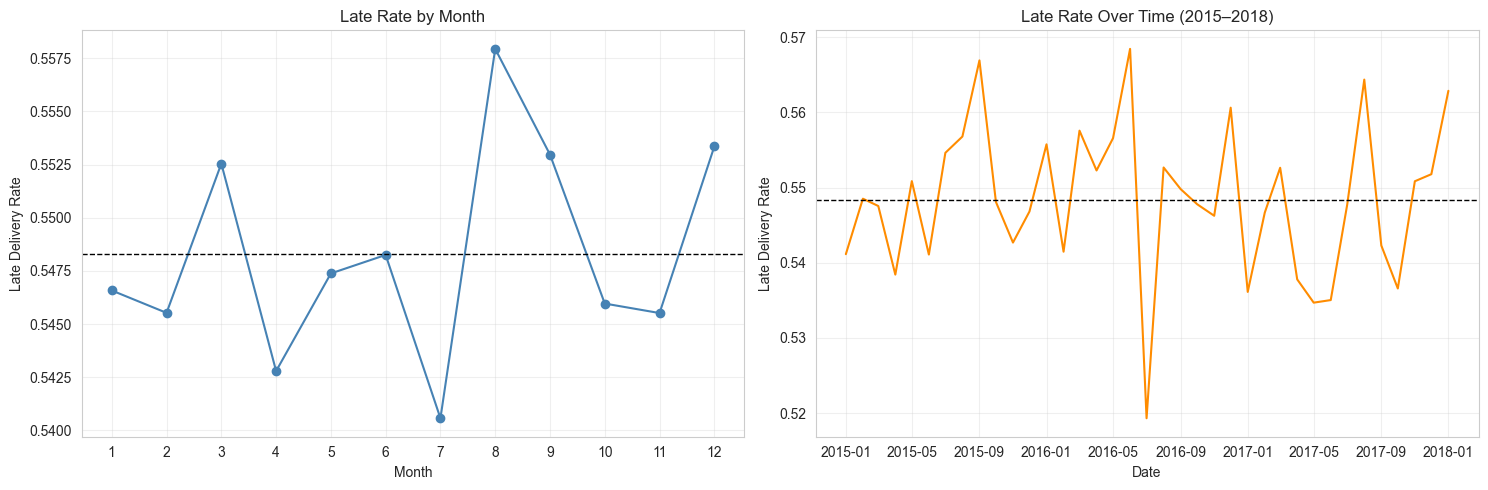

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Late rate by month
late_by_month = df.groupby('order_month')['Late_delivery_risk'].mean()
axes[0].plot(late_by_month.index, late_by_month.values, marker='o', color='steelblue')
axes[0].axhline(df['Late_delivery_risk'].mean(), color='black', linestyle='--', linewidth=1)
axes[0].set_title('Late Rate by Month')
axes[0].set_xlabel('Month')
axes[0].set_ylabel('Late Delivery Rate')
axes[0].set_xticks(range(1, 13))
axes[0].grid(alpha=0.3)

# Late rate over time (year-month trend)
monthly_trend = df.groupby(df['order_date'].dt.to_period('M'))['Late_delivery_risk'].mean()
monthly_trend.index = monthly_trend.index.to_timestamp()
axes[1].plot(monthly_trend.index, monthly_trend.values, color='darkorange')
axes[1].axhline(df['Late_delivery_risk'].mean(), color='black', linestyle='--', linewidth=1)
axes[1].set_title('Late Rate Over Time (2015–2018)')
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Late Delivery Rate')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Time & Seasonality

Late rate is essentially flat over time — note the y-axis spans only ~2 percentage points. No seasonal pattern, no holiday spike, no year-over-year trend; just noise around 55%.



**Summary of all EDA dimensions:**
- Shipping Mode → huge effect (38%–95%)
- Geography → flat (~55%)
- Customer Segment → flat (55%)
- Time/Season → flat (~55%)

**Takeaway:** Late delivery is driven almost entirely by shipping mode — it's a structural problem in how delivery windows are promised, not a regional, customer, or seasonal one.

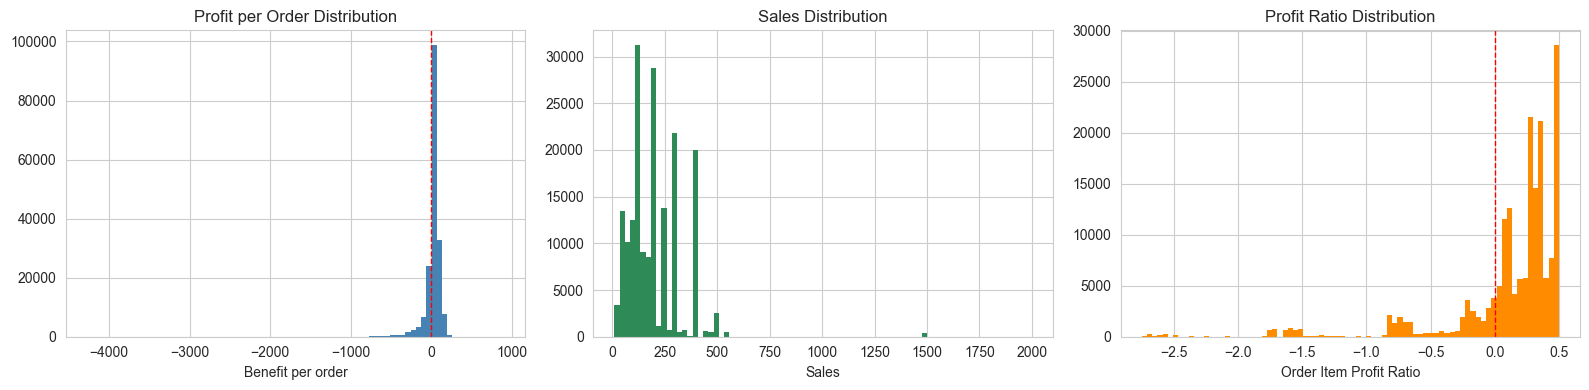

Orders with negative profit: 18.7%

Profit per order summary:
count    180519.00
mean         21.97
std         104.43
min       -4274.98
25%           7.00
50%          31.52
75%          64.80
max         911.80
Name: Benefit per order, dtype: float64


In [16]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Profit distribution (Benefit per order)
axes[0].hist(df['Benefit per order'], bins=80, color='steelblue', edgecolor='none')
axes[0].axvline(0, color='red', linestyle='--', linewidth=1)
axes[0].set_title('Profit per Order Distribution')
axes[0].set_xlabel('Benefit per order')

# Sales distribution
axes[1].hist(df['Sales'], bins=80, color='seagreen', edgecolor='none')
axes[1].set_title('Sales Distribution')
axes[1].set_xlabel('Sales')

# Profit ratio distribution
axes[2].hist(df['Order Item Profit Ratio'], bins=80, color='darkorange', edgecolor='none')
axes[2].axvline(0, color='red', linestyle='--', linewidth=1)
axes[2].set_title('Profit Ratio Distribution')
axes[2].set_xlabel('Order Item Profit Ratio')

plt.tight_layout()
plt.show()

# How many orders are loss-making?
loss_orders = (df['Benefit per order'] < 0).mean()
print(f"Orders with negative profit: {loss_orders:.1%}")
print(f"\nProfit per order summary:")
print(df['Benefit per order'].describe().round(2))

### Financial Analysis

**18.7% of orders are loss-making**, with extreme losses down to −$4,275 per order.

Profit is heavily left-skewed: most orders earn small margins (median ~$32), but a minority of deep-loss orders drag the average down.

**These extreme-loss orders are prime candidates for anomaly detection**  — they may signal pricing errors, excessive discounting, or fraud.


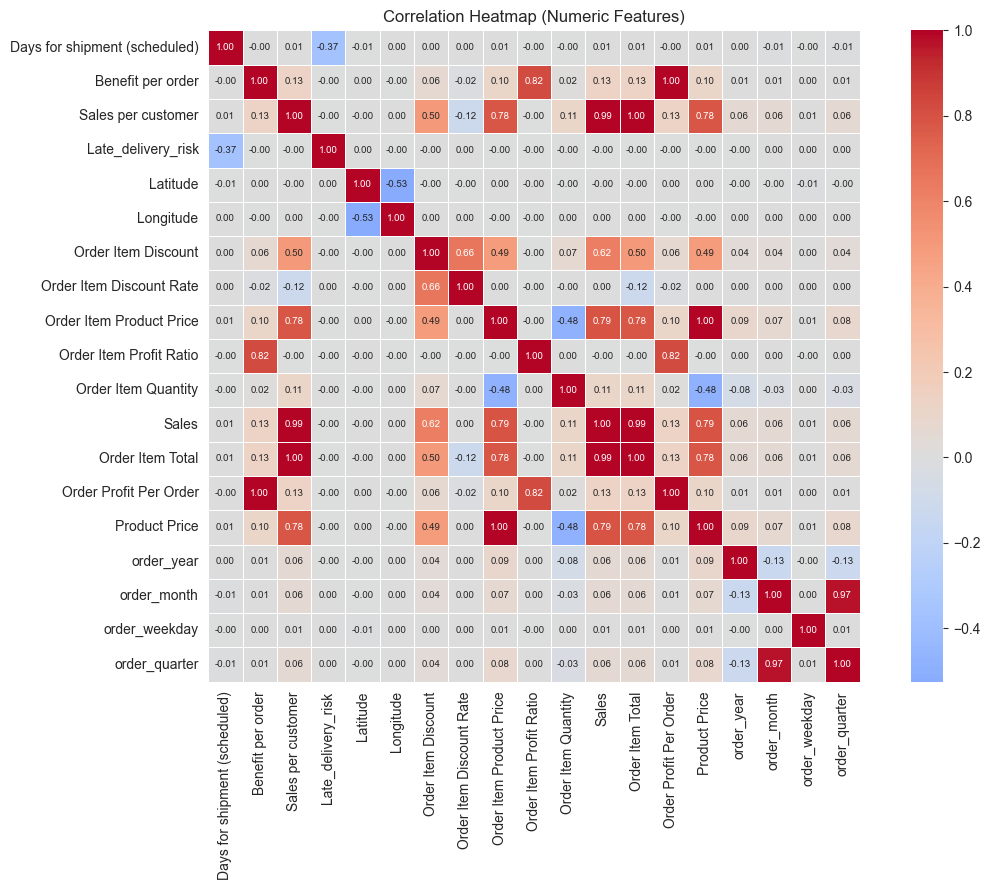

In [17]:
# numeric columns only
num_cols = df.select_dtypes(include=[np.number]).columns
corr = df[num_cols].corr()

plt.figure(figsize=(12, 9))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5, annot_kws={'size': 7})
plt.title('Correlation Heatmap (Numeric Features)')
plt.tight_layout()
plt.show()

### Correlation Heatmap

**Two key findings:**

1. **Severe multicollinearity among money columns.** Sales, Sales per customer, and Order Item Total are ~0.99–1.00 correlated; Benefit per order = Order Profit Per Order (1.00); Order Item Product Price = Product Price (1.00). These are near-duplicate features carrying the same information — the clearest possible justification for PCA (Phase 6) and for keeping only one column per group when modeling.

2. **The target has almost no linear correlation with numeric features** — every value in the `Late_delivery_risk` row is ~0.00 except `Days for shipment (scheduled)` at −0.37. This confirms (numerically) what the EDA showed: late delivery is driven by shipping-window promises, not financial or geographic variables.

In [18]:
# 1 if order placed on Sat(5) or Sun(6), else 0
df['is_weekend'] = (df['order_weekday'] >= 5).astype(int)

In [19]:
# rank shipping modes by promised speed (faster promise = higher late risk)
df['shipping_speed_rank'] = df['Shipping Mode'].map({
    'Same Day': 1,
    'First Class': 2,
    'Second Class': 3,
    'Standard Class': 4
})

In [20]:
# per-unit profit = total profit / quantity
df['profit_per_unit'] = df['Benefit per order'] / df['Order Item Quantity']

# check for division-by-zero artifacts
print("Infinities:", np.isinf(df['profit_per_unit']).sum())
print("NaNs:", df['profit_per_unit'].isna().sum())
print("Min quantity:", df['Order Item Quantity'].min())

Infinities: 0
NaNs: 0
Min quantity: 1


In [21]:
# 1 if discount rate above 20%, else 0
df['high_discount_flag'] = (df['Order Item Discount Rate'] > 0.2).astype(int)
# how the discount rate is distributed, and how many orders exceed 20%
print(df['Order Item Discount Rate'].describe().round(3))
print("\nShare flagged as high-discount:", df['high_discount_flag'].mean().round(3))

count    180519.000
mean          0.102
std           0.070
min           0.000
25%           0.040
50%           0.100
75%           0.160
max           0.250
Name: Order Item Discount Rate, dtype: float64

Share flagged as high-discount: 0.111


### Feature Engineering Summary

Engineered business-focused, leakage-free features to improve late-delivery prediction performance:

- **is_weekend** — identifies whether the order was placed on a weekend
- **shipping_speed_rank** — numerical ranking of shipping modes based on promised delivery speed
- **profit_per_unit** — normalized profit metric calculated per ordered item
- **high_discount_flag** — flags heavily discounted orders (>20%), which may influence operational pressure and delivery delays

A category-based late-rate feature was explored but intentionally removed due to target leakage risk and weak predictive value.

In [22]:
df.to_csv('../data/processed/features_supply_chain.csv', index=False)
print('Saved:', df.shape)

Saved: (180519, 39)


In [23]:
# count unique values in the text columns 
text_cols = df.select_dtypes(include='object').columns
print(df[text_cols].nunique().sort_values(ascending=False))

Order City          3597
Order State         1089
Customer City        563
Order Country        164
Product Name         118
Category Name         50
Customer State        46
Order Region          23
Department Name       11
Order Status           9
Market                 5
Type                   4
Shipping Mode          4
Customer Segment       3
Customer Country       2
dtype: int64


In [24]:
# === FEATURE SELECTION FOR DELIVERY-RISK MODEL ===

target = 'Late_delivery_risk'

# redundant — one kept per collinear group (heatmap showed 0.99+ correlation)
redundant = [
    'Sales', 'Sales per customer', 'Order Item Total',
    'Order Profit Per Order', 'Product Price',
]

# high cardinality — too many unique values to one-hot (verified via nunique)
high_cardinality = [
    'Customer City', 'Customer Country', 'Customer State',
    'Order City', 'Order Country', 'Order Region',
    'Product Name', 'Category Name', 'Department Name', 'Market', 'Order State',
]

# raw fields replaced by engineered versions
encoded_raw = ['Shipping Mode', 'order_date']

# leakage — Order Status encodes post-outcome info (CANCELED, etc.)
leakage = ['Order Status']

cols_to_drop = redundant + high_cardinality + encoded_raw + leakage

X = df.drop(columns=[target] + cols_to_drop)
y = df[target]

print('X shape:', X.shape)
print('y shape:', y.shape)
print('\nFeatures going into model:')
print(X.columns.tolist())

X shape: (180519, 19)
y shape: (180519,)

Features going into model:
['Type', 'Days for shipment (scheduled)', 'Benefit per order', 'Customer Segment', 'Latitude', 'Longitude', 'Order Item Discount', 'Order Item Discount Rate', 'Order Item Product Price', 'Order Item Profit Ratio', 'Order Item Quantity', 'order_year', 'order_month', 'order_weekday', 'order_quarter', 'is_weekend', 'shipping_speed_rank', 'profit_per_unit', 'high_discount_flag']


In [25]:
X.dtypes

Type                              object
Days for shipment (scheduled)      int64
Benefit per order                float64
Customer Segment                  object
Latitude                         float64
Longitude                        float64
Order Item Discount              float64
Order Item Discount Rate         float64
Order Item Product Price         float64
Order Item Profit Ratio          float64
Order Item Quantity                int64
order_year                         int64
order_month                        int64
order_weekday                      int64
order_quarter                      int64
is_weekend                         int64
shipping_speed_rank                int64
profit_per_unit                  float64
high_discount_flag                 int64
dtype: object

In [26]:
# one-hot encode the two low-cardinality text columns
# drop_first=True avoids redundancy (n categories → n-1 columns)
X = pd.get_dummies(X, columns=['Type', 'Customer Segment'], drop_first=True).astype(int)

print('X shape:', X.shape)
print('\nColumns now:')
print(X.columns.tolist())

X shape: (180519, 22)

Columns now:
['Days for shipment (scheduled)', 'Benefit per order', 'Latitude', 'Longitude', 'Order Item Discount', 'Order Item Discount Rate', 'Order Item Product Price', 'Order Item Profit Ratio', 'Order Item Quantity', 'order_year', 'order_month', 'order_weekday', 'order_quarter', 'is_weekend', 'shipping_speed_rank', 'profit_per_unit', 'high_discount_flag', 'Type_DEBIT', 'Type_PAYMENT', 'Type_TRANSFER', 'Customer Segment_Corporate', 'Customer Segment_Home Office']


In [27]:
X.head()

,Days for shipment (scheduled),Benefit per order,Latitude,Longitude,Order Item Discount,Order Item Discount Rate,Order Item Product Price,Order Item Profit Ratio,Order Item Quantity,order_year,order_month,order_weekday,order_quarter,is_weekend,shipping_speed_rank,profit_per_unit,high_discount_flag,Type_DEBIT,Type_PAYMENT,Type_TRANSFER,Customer Segment_Corporate,Customer Segment_Home Office
0,4,91,18,-66,13,0,327,0,1,2018,1,2,1,0,4,91,0,1,0,0,0,0
1,4,-249,18,-66,16,0,327,0,1,2018,1,5,1,1,4,-249,0,0,0,1,0,0
2,4,-247,37,-121,18,0,327,0,1,2018,1,5,1,1,4,-247,0,0,0,0,0,0
3,4,22,34,-118,22,0,327,0,1,2018,1,5,1,1,4,22,0,1,0,0,0,1
4,4,134,18,-66,29,0,327,0,1,2018,1,5,1,1,4,134,0,0,1,0,1,0


In [28]:
print(y.value_counts())
print(y.value_counts(normalize=True))

Late_delivery_risk
1    98977
0    81542
Name: count, dtype: int64
Late_delivery_risk
1    0.548291
0    0.451709
Name: proportion, dtype: float64


In [29]:
from sklearn.dummy import DummyClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

dummy = DummyClassifier(strategy='most_frequent')
dummy.fit(X_train, y_train)
dummy_pred = dummy.predict(X_test)

print('Baseline accuracy:', accuracy_score(y_test, dummy_pred))
print('Baseline F1:', f1_score(y_test, dummy_pred))

Baseline accuracy: 0.5483048969643253
Baseline F1: 0.7082647584973166


In [30]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [31]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score

logreg = LogisticRegression(max_iter=1000, class_weight='balanced')
logreg.fit(X_train_scaled, y_train)
logreg_pred = logreg.predict(X_test_scaled)

print(classification_report(y_test, logreg_pred))
print('ROC-AUC:', roc_auc_score(y_test, logreg.predict_proba(X_test_scaled)[:, 1]))

              precision    recall  f1-score   support

           0       0.62      0.82      0.71     16308
           1       0.80      0.59      0.68     19796

    accuracy                           0.69     36104
   macro avg       0.71      0.70      0.69     36104
weighted avg       0.72      0.69      0.69     36104

ROC-AUC: 0.724809518333011


In [32]:
from sklearn.ensemble import RandomForestClassifier


rf = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

print(classification_report(y_test, rf_pred))
print('ROC-AUC:', roc_auc_score(y_test, rf.predict_proba(X_test)[:, 1]))

              precision    recall  f1-score   support

           0       0.65      0.83      0.73     16308
           1       0.82      0.62      0.71     19796

    accuracy                           0.72     36104
   macro avg       0.73      0.73      0.72     36104
weighted avg       0.74      0.72      0.72     36104

ROC-AUC: 0.7962597991170474


In [33]:
from xgboost import XGBClassifier

# XGBoost: gradient boosting, typically the top performer on tabular data
# scale_pos_weight handles imbalance (ratio of negative/positive class)
xgb = XGBClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1,
    eval_metric='logloss'
)
xgb.fit(X_train, y_train)
xgb_pred = xgb.predict(X_test)

print(classification_report(y_test, xgb_pred))
print('ROC-AUC:', roc_auc_score(y_test, xgb.predict_proba(X_test)[:, 1]))

              precision    recall  f1-score   support

           0       0.63      0.84      0.72     16308
           1       0.81      0.59      0.68     19796

    accuracy                           0.70     36104
   macro avg       0.72      0.71      0.70     36104
weighted avg       0.73      0.70      0.70     36104

ROC-AUC: 0.7606826043351282


In [34]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 20, 30],
    'min_samples_split': [2, 5],
    'max_features': ['sqrt', 'log2']
}


rf_base = RandomForestClassifier(
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)


grid_search = GridSearchCV(
    rf_base,
    param_grid,
    scoring='roc_auc',
    cv=3,
    n_jobs=-1,
    verbose=2
)

grid_search.fit(X_train, y_train)

print('Best params:', grid_search.best_params_)
print('Best CV ROC-AUC:', grid_search.best_score_)

Fitting 3 folds for each of 24 candidates, totalling 72 fits
[CV] END max_depth=None, max_features=sqrt, min_samples_split=5, n_estimators=100; total time=  14.4s
[CV] END max_depth=None, max_features=sqrt, min_samples_split=2, n_estimators=100; total time=  15.0s
[CV] END max_depth=None, max_features=sqrt, min_samples_split=5, n_estimators=100; total time=  14.8s
[CV] END max_depth=None, max_features=sqrt, min_samples_split=2, n_estimators=100; total time=  15.6s
[CV] END max_depth=None, max_features=sqrt, min_samples_split=2, n_estimators=100; total time=  15.6s
[CV] END max_depth=None, max_features=sqrt, min_samples_split=5, n_estimators=100; total time=  13.9s
[CV] END max_depth=None, max_features=sqrt, min_samples_split=2, n_estimators=200; total time=  29.0s
[CV] END max_depth=None, max_features=sqrt, min_samples_split=2, n_estimators=200; total time=  29.9s
[CV] END max_depth=None, max_features=sqrt, min_samples_split=2, n_estimators=200; total time=  29.9s
[CV] END max_depth=No

In [35]:
best_rf = grid_search.best_estimator_
best_rf_pred = best_rf.predict(X_test)

print(classification_report(y_test, best_rf_pred))
print('ROC-AUC:', roc_auc_score(y_test, best_rf.predict_proba(X_test)[:, 1]))

              precision    recall  f1-score   support

           0       0.65      0.84      0.73     16308
           1       0.83      0.62      0.71     19796

    accuracy                           0.72     36104
   macro avg       0.74      0.73      0.72     36104
weighted avg       0.74      0.72      0.72     36104

ROC-AUC: 0.7998619739096944


In [36]:
import pandas as pd
from sklearn.metrics import recall_score

results = pd.DataFrame({
    'Model': ['Dummy (baseline)', 'Logistic Regression', 'Random Forest', 'XGBoost', 'Random Forest (tuned)'],
    'Accuracy': [
        accuracy_score(y_test, dummy_pred),
        accuracy_score(y_test, logreg_pred),
        accuracy_score(y_test, rf_pred),
        accuracy_score(y_test, xgb_pred),
        accuracy_score(y_test, best_rf_pred)
    ],
    'Late Recall': [
        recall_score(y_test, dummy_pred),
        recall_score(y_test, logreg_pred),
        recall_score(y_test, rf_pred),
        recall_score(y_test, xgb_pred),
        recall_score(y_test, best_rf_pred)
    ],
    'ROC-AUC': [
        0.5,  # dummy can't rank — no meaningful probabilities
        roc_auc_score(y_test, logreg.predict_proba(X_test_scaled)[:, 1]),
        roc_auc_score(y_test, rf.predict_proba(X_test)[:, 1]),
        roc_auc_score(y_test, xgb.predict_proba(X_test)[:, 1]),
        roc_auc_score(y_test, best_rf.predict_proba(X_test)[:, 1])
    ]
})

results = results.round(3).sort_values('ROC-AUC', ascending=False).reset_index(drop=True)
results

,Model,Accuracy,Late Recall,ROC-AUC
0,Random Forest (tuned),0.719,0.619,0.800
1,Random Forest,0.719,0.624,0.796
2,XGBoost,0.699,0.587,0.761
3,Logistic Regression,0.692,0.588,0.725
4,Dummy (baseline),0.548,1.000,0.500


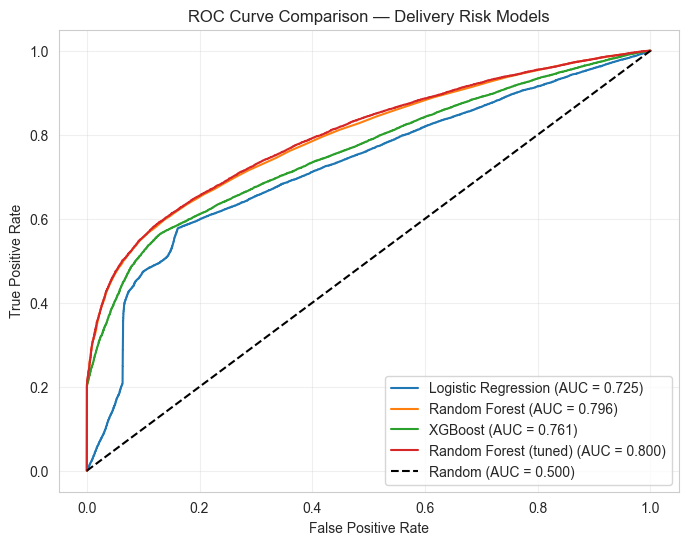

In [37]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve

models = {
    'Logistic Regression': logreg.predict_proba(X_test_scaled)[:, 1],
    'Random Forest': rf.predict_proba(X_test)[:, 1],
    'XGBoost': xgb.predict_proba(X_test)[:, 1],
    'Random Forest (tuned)': best_rf.predict_proba(X_test)[:, 1]
}

plt.figure(figsize=(8, 6))

for name, probs in models.items():
    fpr, tpr, _ = roc_curve(y_test, probs)
    auc = roc_auc_score(y_test, probs)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random (AUC = 0.500)')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison — Delivery Risk Models')
plt.legend()
plt.grid(alpha=0.3)
plt.savefig('../images/roc_curve_comparison.png', dpi=150, bbox_inches='tight')
plt.show()